In [1]:
import qiskit_metal as metal
from qiskit_metal import designs, draw, MetalGUI, Dict
import numpy as np
import pint
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science', 'no-latex', 'notebook'])
from qiskit_metal.qlibrary.qubits.circle_transmon_squid import CircTransmonSQUID

design = designs.DesignPlanar()
design.renderers.qt.gds_renderer.options.plot_col_short = True
gui = MetalGUI(design)

In [2]:
gui.canvas.draw_bbox = True

In [3]:
x_size = 5 #mm
y_size = 5 #mm

design.overwrite_enabled = True
design.chips.main.size.size_x = f'{x_size}mm'
design.chips.main.size.size_y = f'{y_size}mm'

# Main branch

In [4]:
from qiskit_metal.qlibrary.terminations.launchpad_wb import LaunchpadWirebond
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander
# from qiskit_metal.qlibrary.tlines.anchored_path import RouteAnchors
from qiskit_metal.qlibrary.terminations.open_to_ground import OpenToGround
from qiskit_metal.qlibrary.tlines.straight_path import RouteStraight
# from qiskit_metal.qlibrary.tlines.pathfinder import RoutePathfinder

# Funciones para el cálculo de parámetros en el circuito
from design_helper import DesignHelper
from chip import Chip
from components import Resonator, Qubit

# inicializamos el helper
k_inductance_ratio = 0.00
helper = DesignHelper(alpha_inductance = k_inductance_ratio)
film_thickness = helper.ureg.Quantity(100, "nm")

# Planteamiento de parámetros objetivo

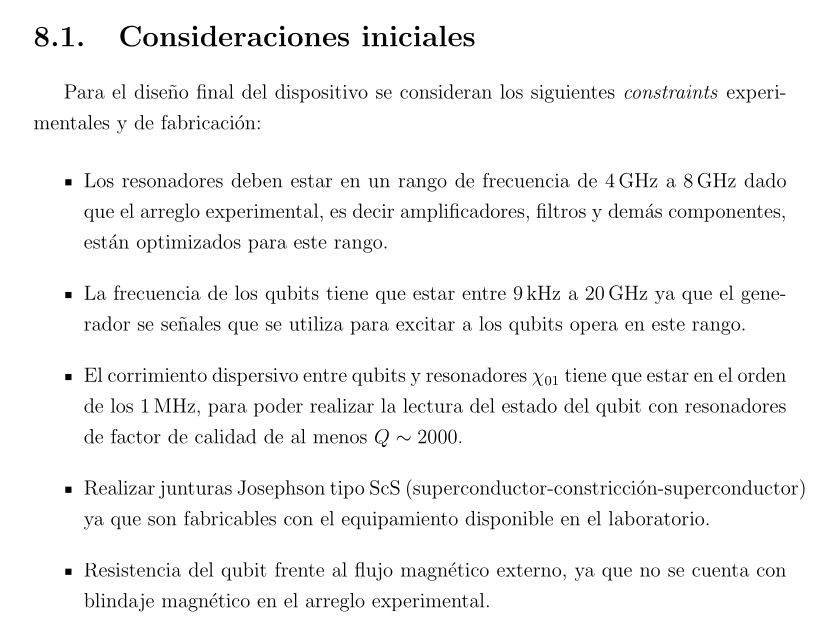

# Readout

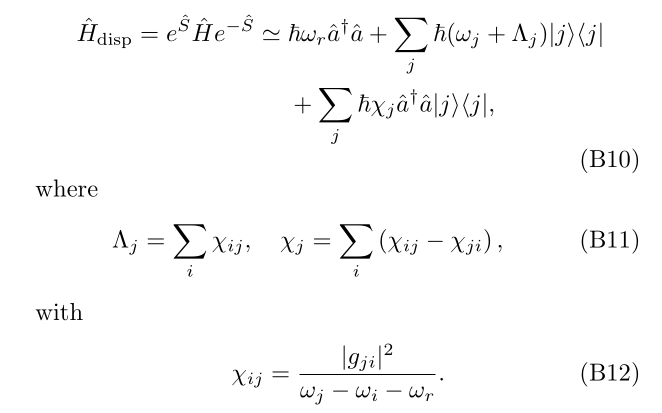

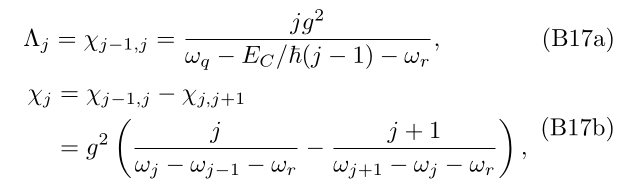

In [ ]:
import numpy as np
from scipy.optimize import minimize_scalar, brentq
import pandas as pd

def estimate_cpw_gap(dh, 
                                target_Z0=50.0,    
                                trace_width=10.0,    
                                thickness=60e-3,     # Kept your 60nm default
                                eps_r=11.9): # Added to support lambda/4, lambda/2, etc.
    """
    Numerically inverts the DesignHelper analytical models to find the 
    geometric parameters for a CPW resonator of arbitrary wavelength ratio.
    """
    print(f"--- Target: Z0={target_Z0} Ω")
    
    # ==========================================
    # 1. Solve for CPW Gap (g) to hit Target Z0
    # ==========================================
    def impedance_error(g_guess):
        params = dh.compute_cpw_geometric_parameters(
            width=trace_width, 
            gap=g_guess, 
            thickness=thickness,
            eps_r=eps_r
        )
        Z0_guess = dh._as_quantity(params['Z0'], 'ohm').magnitude
        return abs(Z0_guess - target_Z0)
    
    res_gap = minimize_scalar(impedance_error, bounds=(1.0, 20.0), method='bounded')
    optimal_g = res_gap.x
    
    # Extract the final phase velocity 
    final_params = dh.compute_cpw_geometric_parameters(
        width=trace_width, 
        gap=optimal_g, 
        thickness=thickness,
        eps_r=eps_r
    )
    
    Z0_final = dh._as_quantity(final_params['Z0'], 'ohm').magnitude
    print(f"1. CPW Geometry: Width = {trace_width} um, Optimal Gap = {optimal_g:.3f} um")
    print(f"   Achieved Z0 = {Z0_final:.2f} Ω")
    
    return optimal_g

def max_distance_ordering(nums):
    """Dada una secuencia de números, crea la secuencia que maximiza las distancia entre elementos semejantes

    Args:
        nums (array): array de números iniciales

    Returns:
        array: array con distancias maximizadas
    """
    nums = sorted(nums)
    result = []
    
    def recurse(lo, hi):
        if lo > hi:
            return
        mid = (lo + hi) // 2
        result.append(nums[mid])
        recurse(lo, mid - 1)
        recurse(mid + 1, hi)
    
    recurse(0, len(nums) - 1)
    return result

def interleave_frequency_groups(freq_lists):
    """
    Given a list of frequency groups (each already sorted),
    interleaves them so that no two frequencies from the same
    group are adjacent. Maximizes inter-group distance.
    
    Example: [[f1, f2], [f3, f4]] -> [f1, f3, f2, f4]
    """
    # Sort each group internally
    groups = [sorted(g) for g in freq_lists]
    result = []
    # Round-robin pick one from each group at a time
    max_len = max(len(g) for g in groups)
    for i in range(max_len):
        for g in groups:
            if i < len(g):
                result.append(g[i])
    return result


In [ ]:
# OJO: trabajamos en unidades de frecuencia, NO DE FRECUENCIA ANGULAR

resonator_width = helper.ureg.Quantity(20, "um")

gap = estimate_cpw_gap(helper, target_Z0=50, trace_width= resonator_width, thickness= film_thickness)
resonator_gap = helper.ureg.Quantity(gap, "um")

chi_target_freq = helper.ureg.Quantity(2.0, "MHz")
chi_target_energy = helper._frequency_as_energy(chi_target_freq)

substrate_epsilon = 11.9

cpw_geometric_parameters = helper.compute_cpw_geometric_parameters(resonator_width, resonator_gap, thickness= film_thickness, eps_r= substrate_epsilon)
Cg_cpw = cpw_geometric_parameters["Cg"]
Lg_cpw = cpw_geometric_parameters["Lg"]
Z0_cpw = cpw_geometric_parameters["Z0"]
v_cpw = cpw_geometric_parameters["v"]
eps_eff_cpw = cpw_geometric_parameters["eps_eff"]


--- Target: Z0=50 Ω
1. CPW Geometry: Width = 20 micrometer um, Optimal Gap = 12.249 um
   Achieved Z0 = 50.00 Ω


In [ ]:
cpw_parameters = helper.compute_cpw_geometric_parameters("20um", "12.25um", "100nm", 11.9)

In [ ]:
cpw_parameters

{'Cg': <Quantity(1.68657974e-10, 'farad / meter')>,
 'Lg': <Quantity(4.21660343e-07, 'henry / meter')>,
 'Z0': <Quantity(50.0009136, 'ohm')>,
 'v': <Quantity(1.1858102e+08, 'meter / second')>,
 'eps_eff': 0.9909490554601347}

In [ ]:
cpw_v = cpw_parameters['v']
target_freq = helper.ureg.Quantity(5, "GHz")
# lambda /4
target_length = 0.25 * (cpw_v / target_freq).to_reduced_units().to("mm")

In [ ]:
target_length

<Quantity(5.929051, 'millimeter')>

# Qubits

In [ ]:
# idealmente esto no es tan bueno que sea tan chiquito, se exhiben mayores variaciones en la fabricación
Ic_base = helper.ureg.Quantity(25, "nA")
Ic_SQUID1 = helper.ureg.Quantity(1500, "nA")
Ic_SQUID2 = helper.ureg.Quantity(1000, "nA")

EJ_base = helper.Ic_to_EJ(Ic_base)
EJ_SQUID1 = helper.Ic_to_EJ(Ic_SQUID1)
EJ_SQUID2 = helper.Ic_to_EJ(Ic_SQUID2)

T = 100.0
EC_base = EJ_base / T
C_base = helper.EC_to_C(EC_base)
anharmonicity = helper.compute_anharmonicity(EC_base, exact_EJ= EJ_base)

freq_base = helper.compute_transmon_frequency(EJ_base, EC_base, 
                                              exact= True, n_levels=10)

second_energy_level = helper.compute_transmon_energy_levels(EC_base, 
                                                            EJ_base, 2, exact= True)[1]
print(f"First transmon level: {freq_base},\nsecond transmon level: {second_energy_level}")

# detuning entre el nivel de interés y el resonador de readout, fijo para todos los pares resonador-qubit
qubit_resonator_detuning = helper.ureg.Quantity(1.0, helper.freq_units) # GHz

# freq_min para readout del primer nivel
first_level_resonator_min = freq_base + qubit_resonator_detuning
 
# freq_min para readout del segundo nivel
second_level_resonator_min = second_energy_level + qubit_resonator_detuning 

print(f"first level readout resonator freq: {first_level_resonator_min},\nsecond level readout resonator freq: {second_level_resonator_min}")

First transmon level: 3.3830523925439886 gigahertz,
second transmon level: 6.630076301994222 gigahertz
first level readout resonator freq: 4.383052392543989 gigahertz,
second level readout resonator freq: 7.630076301994222 gigahertz


In [ ]:
# readout resonators frequencies

# detuning minimo entre resonadores similares
resonator_resonator_detuning = helper.ureg.Quantity(0.5, helper.freq_units) # GHz

# frecuencias objetivo para cada uno de los resonadores
f1 = first_level_resonator_min
f2 = first_level_resonator_min + resonator_resonator_detuning
f3 = second_level_resonator_min
f4 = second_level_resonator_min + resonator_resonator_detuning
group_first_level  = [f1.magnitude, f2.magnitude]
group_second_level = [f3.magnitude, f4.magnitude]

freqs_ordered = interleave_frequency_groups([group_first_level, group_second_level])

resonator_frequencies = [
    helper.ureg.Quantity(freq, "GHz") for freq in freqs_ordered
]

#longitudes para que sean resonadores lambda / 4 (lambda/2 eran demasiado largos)

resonator_lengths = [(v_cpw / (4 * freq)).to_reduced_units().to("um") for freq in resonator_frequencies]

# Capacitancia, inductancia e impedancia total de los resonadores
resonator_capacitances = [(Cg_cpw * ell).to_reduced_units().to(helper.capacitance_units) for ell in resonator_lengths]
resonator_inductances = [(Lg_cpw * ell).to_reduced_units().to(helper.inductance_units) for ell in resonator_lengths]
resonator_names = ["cpw1(omega_r ~ omega_q)", "cpw1(omega_r ~ 2omega_q)", "cpw2(omega_r ~ omega_q)", "cpw2(omega_r ~ 2omega_q)"]

# factores de calidad optimos para fast readout
resonator_target_Q = [(fr / chi_target_freq).to_reduced_units().magnitude for fr in resonator_frequencies]

In [ ]:
def get_g_target(qubit_freq, resonator_freq, anharmonicity, qubit_level, chi_target):
    """Calcula magnitud de acoplamiento necesaria entre un qubit y un resonador para llegar a un dispersive shift objetivo

    Args:
        qubit_freq (_type_): _description_
        resonator_freq (_type_): _description_
        anharmonicity (_type_): _description_
        qubit_level (_type_): _description_
        chi_target (_type_): _description_

    Raises:
        RuntimeError: _description_

    Returns:
        _type_: _description_
    """
    chi_target = chi_target.to(helper.freq_units)
    chi_target_mag = helper._as_quantity(chi_target, helper.freq_units).magnitude

    def residual(g_mag):
        chi = helper.compute_level_dependent_dispersive_shift(
            g_mag, qubit_freq, resonator_freq, anharmonicity, level=qubit_level
        )
        return chi.magnitude - chi_target_mag

    g_lo, g_hi = 1e-4, 0.5
    f_lo = residual(g_lo)
    f_hi = residual(g_hi)

    if f_lo * f_hi > 0:
        raise RuntimeError(
            f"Root not bracketed: residual({g_lo})={f_lo:.4f}, "
            f"residual({g_hi})={f_hi:.4f}."
        )

    g_solution = brentq(residual, g_lo, g_hi, xtol=1e-6)
    return helper.ureg.Quantity(g_solution, helper.freq_units)

# frecuencia del nivel objetivo en cada qubit y su respectivo resonador, nivel del qubit utilizado
pairings = [
    (freq_base,           resonator_frequencies[0], 1),  # 3.38 -> 4.38
    (second_energy_level, resonator_frequencies[1], 2),  # 6.63 -> 7.63
    (freq_base,           resonator_frequencies[2], 1),  # 3.38 -> 4.88
    (second_energy_level, resonator_frequencies[3], 2),  # 6.63 -> 8.13
]

# array de acoplamientos objetivo para lograr el dispersive shift deseado
g_targets = []
for i, (fq, fr, level) in enumerate(pairings):
    g = get_g_target(fq, fr, anharmonicity, level, chi_target_freq)
    g_targets.append(g)
    

resistance_quantum = (helper.planck / helper.ureg.Quantity(1.0, "elementary_charge")**2).to_reduced_units().to(helper.resistance_units)
phi_zpf, n_zpf = helper.compute_transmon_zpfs(EJ_base, EC_base)

prefactors = [
    (2*np.pi * res_fr * phi_zpf * np.sqrt(np.pi * Z0_cpw / resistance_quantum) / C_base).to_reduced_units() for res_fr in resonator_frequencies]

#Capacitancia de acoplamiento objetivo para llegar a la magnitud de acoplamiento deseada
Cg_targets = [(g_target / pref).to_reduced_units().to(helper.capacitance_units) for g_target, pref in zip(g_targets, prefactors)]

# Capacitancia entre el meandro y el feedline necesaria para que el factor de calidad sea del mismo orden que el dispersive shift
C_feedline_targets = [helper.compute_Cc_from_Qc(resonator_width, resonator_gap, film_thickness, substrate_epsilon, ell, Qc, wavelength_ratio=0.25) for ell, Qc in zip(resonator_lengths, resonator_target_Q)]

# Resumen de los datos obtenidos
resonator_df = pd.DataFrame({
    "NAME" : resonator_names,
    "Frequency (GHz)": [round(f.magnitude, 4) for f in resonator_frequencies],
    "Length (um)":     [round(l.magnitude, 2) for l in resonator_lengths],
    "Capacitance (fF)": [round(c.magnitude, 2) for c in resonator_capacitances],
    "Inductance (nH)": [round(l.magnitude, 2) for l in resonator_inductances],
    "Qc": [round(Q) for Q in resonator_target_Q],
    "gc (MHz)": [round(g.to("MHz").magnitude, 2) for g in g_targets],
    "Cg (fF)": [round(Cg.magnitude, 2) for Cg in Cg_targets],
    "C_feedline (fF)": [round(Cf.magnitude, 2) for Cf in C_feedline_targets]
})

resonator_df.index.name = "Resonator"
resonator_df

,NAME,Frequency (GHz),Length (um),Capacitance (fF),Inductance (nH),Qc,gc (MHz),Cg (fF),C_feedline (fF)
Resonator,,,,,,,,,
0,cpw1(omega_r ~ omega_q),4.3831,6763.61,1140.76,2.85,2192,39.00,7.53,19.44
1,cpw1(omega_r ~ 2omega_q),7.6301,3885.32,655.30,1.64,3815,33.28,3.69,8.47
2,cpw2(omega_r ~ omega_q),4.8831,6071.05,1023.95,2.56,2442,50.01,8.67,16.53
3,cpw2(omega_r ~ 2omega_q),8.1301,3646.37,615.00,1.54,4065,45.25,4.71,7.70


In [ ]:
# usamos un valor igual al del aluminio bulk normal ya que la resistencia del film logrado en el laboratorio es muy chiquita

gap_energy = helper._energy_as_frequency(172.0 * helper.ureg.microeV)

full_resistance = helper.ureg.Quantity(5377, helper.resistance_units)
short_resistance = helper.ureg.Quantity(130, helper.resistance_units)
tunnel_resistance = full_resistance - short_resistance
working_temperature = helper.ureg.Quantity(10, "mK")
print(
    helper.Rn_to_EJ(tunnel_resistance, gap_energy, temperature = working_temperature)
)

{'Ic': <Quantity(51.4917035, 'nanoampere')>, 'EJ': <Quantity(25.5750801, 'gigahertz')>}


# Cavities

In [ ]:
# Longitud de los resonadores que hacen de cavidad en los qubits, sus frecuencias tienen que coincidir con el nivel del qubit deseado


target_cavity_frequencies = [freq_base, second_energy_level, freq_base, second_energy_level]

wavelength_ratio = 0.5 # cavities lambda/2
target_cavity_lengths = [(wavelength_ratio * v_cpw / cavity_fr).to_reduced_units().to("um") for cavity_fr in target_cavity_frequencies]



cavity_df = pd.DataFrame({
    "NAME" : resonator_names,
    "Frequency (GHz)": [round(f.magnitude, 4) for f in target_cavity_frequencies],
    "Length (um)":     [round(l.magnitude, 2) for l in target_cavity_lengths]
})
cavity_df

,NAME,Frequency (GHz),Length (um)
0,cpw1(omega_r ~ omega_q),3.3831,17525.75
1,cpw1(omega_r ~ 2omega_q),6.6301,8942.66
2,cpw2(omega_r ~ omega_q),3.3831,17525.75
3,cpw2(omega_r ~ 2omega_q),6.6301,8942.66


# Circuit elements

## Main branch

In [ ]:
pad_1_options = dict(
        pos_x = "-2000um",
        pos_y = "0um",
        orientation = "0"
    )

pad_2_options = dict(
        pos_x = "2000um",
        pos_y = "0um",
        orientation = "180"
    )

try:
    pad_1.delete()
    pad_2.delete()
except NameError : pass

pad_1 = LaunchpadWirebond(
    design, 
    "pad_1",
    options = pad_1_options
)
pad_2 = LaunchpadWirebond(
    design, 
    "pad_2",
    options = pad_2_options
)

gui.rebuild()
gui.autoscale()

In [ ]:
from collections import OrderedDict

try:
    main_branch.delete()
except NameError: pass

main_branch_options = {
    "pin_inputs": {
        "start_pin": {
            "component": "pad_1", 
            "pin": "tie"
            },
        "end_pin": {
            "component": "pad_2", 
            "pin": "tie"
            }
    }
}

main_branch = RouteStraight(design, "main_branch", main_branch_options)
gui.rebuild()
# gui.autoscale()

## Readout resonators

In [7]:
N = 4
readout_x_positions = np.linspace(-2000, 2000, N+2)[1:-1]
print(readout_x_positions)

[-1200.  -400.   400.  1200.]


In [9]:
fillet='99.99um'
cpw_options = Dict(
    lead=Dict(
        start_straight='100um',
        end_straight='100um'),
    fillet=fillet
    )

def connect(cpw_name: str, pin1_comp_name: str, pin1_comp_pin: str, pin2_comp_name: str, pin2_comp_pin: str,
            length: str, asymmetry='0 um'):
    """Connect two pins with a CPW."""
    myoptions = Dict(
        pin_inputs=Dict(
            start_pin=Dict(
                component=pin1_comp_name,
                pin=pin1_comp_pin),
            end_pin=Dict(
                component=pin2_comp_name,
                pin=pin2_comp_pin)),
        total_length=length)
    myoptions.update(cpw_options)
    myoptions.meander.asymmetry = asymmetry
    return RouteMeander(design, cpw_name, myoptions)

In [10]:
# Creamos las terminaciones a ground necesarias cerca del main

launch_point1 = OpenToGround(design, "launch_point1", options= dict(
    pos_x = "-1000um",
    pos_y = "-100um",
    orientation = "180",
    termination_gap = "6um"
)
)


In [7]:
meander_1_options = dict(
    pin_inputs = dict(
        start_pin = dict(
            component = "Q1_SQUID",
            pin = "claw_a"
        ),
        end_pin = dict(
            component = "launch_point1",
            pin = "open"
        ),
        lead = dict(
            start_straight = "100um",
            end_straight = "100um",
            fillet = '40um'
        ),
        meander = dict(
            assymetry = "0um",
            efficiency = "0.7",
            spacing = "200um"
        ),
        total_length = "4.5mm",
        trace_width = "10um",
        trace_gap = '6um'
    )
)
readout_1 = RouteMeander(design, "readout_1", options = meander_1_options)
gui.rebuild()
gui.autoscale()

07:40PM 26s WARNING [__init__]: Component Q1_SQUID does not exist. readout_1 has not been built. Please check your pin_input values.


In [12]:
meander_1_options.items

<function dict.items>

In [8]:
from qiskit_metal.qlibrary.resonators.readoutres_fc import ReadoutResFC

readout_res1_options = dict(
    # --- Placement ---
    pos_x = '0um',                    # Center X coordinate of the readout claw
    pos_y = '0um',                    # Center Y coordinate of the readout claw
    
    # --- Coupling & Claw Geometry ---
    readout_radius = '50um',          # Distance/radius of the circular claw. VARY THIS to change qubit coupling.
    
    # --- CPW Transmission Line Properties ---
    readout_cpw_width = '10um',       # Width of the center trace
    readout_cpw_gap = '6um',          # Width of the gap between the trace and ground
    readout_cpw_turnradius = '30um',  # Bend radius for all arcs (measured from the trace center)
    
    # --- Routing & Lengths ---
    readout_l1 = '100um',             # Length of the first straight line at 45 degrees
    readout_l2 = '100um',             # Length of the vertical drop
    readout_l3 = '500um',             # Horizontal line length. USE THIS SECTION to couple to your feedline.
    readout_l4 = '100um',             # Short horizontal segment before the meander begins
    readout_l5 = '800um'              # Length of the 5 meandering horizontal lines. VARY THIS to adjust resonance frequency.
)

try:
    readout_res1.delete()
except NameError: pass

# readout_res1 = ReadoutResFC(
#     design,
#     "readout_res1",
#     readout_res1_options
# )
gui.rebuild()
gui.autoscale()

# Qubits

In [9]:


T = 75
Ic_main = helper.ureg.Quantity(100, "nA")
Ic_SQUID1 = helper.ureg.Quantity(1500, "nA")
Ic_SQUID2 = helper.ureg.Quantity(1000, "nA")

EJ_main = helper.Ic_to_EJ(Ic_main)

EC_obj =  EJ_main/ T
C_obj = helper.EC_to_C(EC_obj)
print(f"Capacitancia objetivo de los transmon: {C_obj}") # 30 fF

# calculamos la frecuencia resultante
transmon_freq = helper.compute_transmon_frequency(EJ_main, EC_obj)
print(f"Frecuencia de transmon resultante: {transmon_freq}")

Capacitancia objetivo de los transmon: 29.24935432379682 femtofarad
Frecuencia de transmon resultante: 15.559370853057835 gigahertz


In [10]:
from qiskit_metal import Dict

options = Dict(
    pos_x='-1000um', pos_y='-800um', orientation='0', chip='main',
    cpw_width='10um', cpw_gap='6um',

    pad_radius='90um',
    pad_gap='10um',

    jj_options=Dict(
        jj_width='5um',
        jj_angle='0',      # single JJ, straight down, away from the SQUID
        L_j='10nH',
        C_j='2fF',
        export_mask=False,
        jj_sim_gap='3um',
    ),

    squid_options=Dict(
        theta_2='180',        # SQUID sits at the top of the pad
        delta_angle='5.0',    # wide enough to see the two prongs clearly
        g1='4um',

        l1='200um',
        w1='6um',
        l2='200um',

        jj_a_options=Dict(
            jj_width='4um', L_j='15nH', C_j='1.5fF',
            export_mask=False, jj_sim_gap='3um',
        ),
        jj_b_options=Dict(
            jj_width='6um', L_j='8nH', C_j='1.8fF',
            export_mask=False, jj_sim_gap='3um',
        ),
    ),
    
    claw_a_options = Dict(
        make_claw = True,
        connector_location = "90",
        claw_width = "10um",
        claw_gap = "6um",
        claw_length = "30um",
        ground_spacing = "5um",
        connector_length = "20um"
    )
)

try:
    qubit_1.delete()
except NameError: 
    pass

# Pass ONLY the single options dictionary
qubit_1 = CircTransmonSQUID(design, 'Q1_SQUID', options=options)

gui.rebuild()
gui.autoscale()